<a href="https://colab.research.google.com/github/yanin-dev/Repositorio-ModelizadoSistemas-/blob/main/_practica_unidad_3_rrnn_multicapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Clasificación de Ropa con Fashion MNIST
**Consigna:** El objetivo de este ejercicio es diseñar, entrenar y evaluar una red neuronal profunda (MLP) capaz de clasificar imágenes de 28x28 píxeles en 10 categorías de vestimenta. Deberás completar las secciones de código indicadas para que el modelo logre una precisión aceptable en el set de prueba.

## 1. Carga de Datos y Preprocesamiento
El primer paso es normalizar las imágenes. Como las redes neuronales son calculadoras de promedios ponderados, es vital que las entradas estén en la misma escala (generalmente entre 0 y 1) para evitar que magnitudes grandes dominen el aprendizaje.

In [ ]:
# Importamos TensorFlow, que es la librería principal para redes neuronales
import tensorflow as tf

# Importamos módulos específicos de Keras (que viene dentro de TensorFlow)
# layers: para crear capas de la red
# models: para armar el modelo
from tensorflow.keras import layers, models

# Librería para mostrar imágenes y gráficos
import matplotlib.pyplot as plt

# Librería para cálculos numéricos (arrays, operaciones matemáticas)
import numpy as np


# ================================
# 1. CARGA DE DATOS
# ================================

# Cargamos el dataset Fashion MNIST (ropa en imágenes de 28x28)
fashion_mnist = tf.keras.datasets.fashion_mnist

# Separamos en datos de entrenamiento y prueba
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()


# Nombres de las clases (las etiquetas)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


# ================================
# NORMALIZACIÓN
# ================================

# Dividimos por 255 para pasar de rango [0,255] a [0,1]
# Esto ayuda a que la red aprenda mejor (evita valores grandes)
train_images = train_images / 255.0
test_images = test_images / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 2. Definición de la Arquitectura (MLP)
Configurar las capas de la red. Recirdar que la Capa de Entrada debe **"aplanar"** la matriz de 28x28. En las Capas Ocultas, utilizamos la función **ReLU** por su eficiencia para transmitir señales positivas . Finalmente, la Capa de Salida debe tener 10 neuronas (una por cada prenda) y usar **Softmax** para entregar una distribución de probabilidad que sume 1 .

In [ ]:
# ================================
# 2. DEFINICIÓN DEL MODELO (MLP)
# ================================

# Creamos un modelo secuencial (las capas van una después de otra)
model = models.Sequential([

    # Capa de entrada: convierte la imagen 28x28 en un vector de 784 valores
    layers.Flatten(input_shape=(28, 28)),

    # Capa oculta con 128 neuronas
    # ReLU permite aprender patrones no lineales
    layers.Dense(128, activation='relu'),

    # Segunda capa oculta con 64 neuronas
    layers.Dense(64, activation='relu'),

    # Capa de salida con 10 neuronas (una por clase)
    # Softmax convierte los valores en probabilidades
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 3. Compilación y Entrenamiento
Para que la red aprenda, aplicamos el algoritmo de Backpropagation. Configuraremos el optimizador para ajustar los pesos y una función de pérdida que mida la discrepancia entre la predicción y la realidad

In [ ]:
# ================================
# 3. COMPILACIÓN
# ================================

# Configuramos cómo va a aprender la red
model.compile(

    # Adam: optimizador que ajusta los pesos automáticamente
    optimizer='adam',

    # Función de error para clasificación multiclase
    loss='sparse_categorical_crossentropy',

    # Métrica para evaluar: precisión (accuracy)
    metrics=['accuracy']
)


# ================================
# EARLY STOPPING
# ================================

# Esto evita el sobreajuste (overfitting)
# Detiene el entrenamiento si deja de mejorar
early_stop = tf.keras.callbacks.EarlyStopping(

    # Observa el error de validación
    monitor='val_loss',

    # Espera 5 épocas antes de detenerse
    patience=5,

    # Recupera los mejores pesos encontrados
    restore_best_weights=True
)


# ================================
# ENTRENAMIENTO
# ================================

history = model.fit(

    # Datos de entrenamiento
    train_images, train_labels,

    # Cantidad máxima de iteraciones
    epochs=30,

    # 20% de los datos se usan para validación
    validation_split=0.2,

    # Aplicamos early stopping
    callbacks=[early_stop]
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8210 - loss: 0.5086 - val_accuracy: 0.8375 - val_loss: 0.4340
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8638 - loss: 0.3768 - val_accuracy: 0.8580 - val_loss: 0.3790
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8761 - loss: 0.3369 - val_accuracy: 0.8717 - val_loss: 0.3544
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8835 - loss: 0.3147 - val_accuracy: 0.8791 - val_loss: 0.3391
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8911 - loss: 0.2948 - val_accuracy: 0.8758 - val_loss: 0.3467
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8937 - loss: 0.2830 - val_accuracy: 0.8734 - val_loss: 0.3452
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8973 - loss: 0.2700 - val_accuracy: 0.8827 - val_loss: 0.3339
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9033 - loss: 0.2584 -

## 4. Evaluación y Predicción
Una vez entrenada, es fundamental evaluar el modelo con datos que nunca ha visto (set de prueba) para verificar su capacidad de generalización y asegurar que no solo memorizó los ejemplos de entrenamiento

313/313 - 1s - 2ms/step - accuracy: 0.8809 - loss: 0.3447

Precisión en el set de prueba: 88.09%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


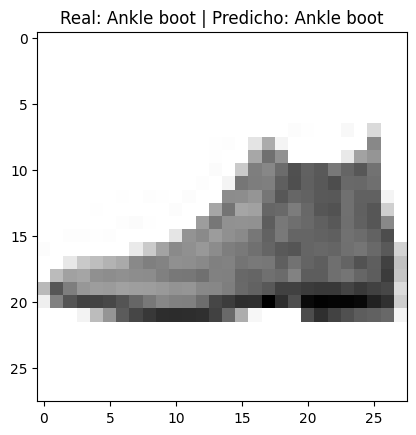

In [ ]:
# ================================
# 4. EVALUACIÓN
# ================================

# Evaluamos con datos que la red nunca vio
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

# Mostramos la precisión final
print(f'\nPrecisión en el set de prueba: {test_acc:.2%}')


# ================================
# PREDICCIONES
# ================================

# El modelo predice probabilidades para cada clase
predictions = model.predict(test_images)


# ================================
# VISUALIZACIÓN
# ================================

# Elegimos una imagen del test
n = 0  # podés cambiar este número

# Mostramos la imagen
plt.imshow(test_images[n], cmap=plt.cm.binary)

# np.argmax elige la clase con mayor probabilidad
plt.title(f"Real: {class_names[test_labels[n]]} | Predicho: {class_names[np.argmax(predictions[n])]}")

plt.show()

## Guía:
- **Normalización:** Si olvidas este paso, notarás que el error (loss) baja muy lentamente o el modelo no converge.
- **Activaciones:** ¿Qué sucede si usas una función lineal en lugar de ReLU en las capas ocultas? La red perdería su capacidad de detectar patrones complejos.
- **Softmax:** Observa cómo las 10 salidas de la última capa compiten entre sí; la prenda con el valor más alto es la elegida por el sistema .